# SurviveX Performance & Accuracy Benchmark

Comparing SurviveX (GPU-accelerated) against lifelines and R

In [1]:
!pip install lifelines --quiet

In [2]:
import numpy as np
import pandas as pd
import torch
import time
import subprocess
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from survivex.models import (
    KaplanMeierEstimator, NelsonAalenEstimator, CoxPHModel, WeibullAFTFitter,
    SurvivalTree, RandomSurvivalForest, GradientBoostingSurvivalAnalysis,
    MultiStateAalenJohansen
)
from survivex.models.multi_state import create_illness_death_matrix, MultiStateData

import lifelines
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines import WeibullAFTFitter as LifelinesWeibullAFT

print(f"lifelines: {lifelines.__version__}")
print(f"PyTorch: {torch.__version__}")

lifelines: 0.30.0
PyTorch: 2.10.0


In [3]:
def progress(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)

R_AVAILABLE = False
try:
    result = subprocess.run(['Rscript', '--version'], capture_output=True, text=True, timeout=5)
    if result.returncode == 0 or 'R scripting' in result.stderr:
        R_AVAILABLE = True
        progress("R detected - will run R benchmarks")
except:
    pass

if not R_AVAILABLE:
    progress("R not available - skipping R benchmarks")

[14:37:11] R detected - will run R benchmarks


In [4]:
def get_device():
    if torch.cuda.is_available():
        return 'cuda', torch.cuda.get_device_name(0)
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps', 'Apple Silicon GPU'
    return 'cpu', 'CPU only'

GPU_DEVICE, GPU_NAME = get_device()
progress(f"Device: {GPU_DEVICE} ({GPU_NAME})")

results = []

[14:37:11] Device: mps (Apple Silicon GPU)


In [5]:
def run_r_script(script, name="R", timeout=120):
    if not R_AVAILABLE:
        return None, None
    try:
        progress(f"  Running {name}...")
        with open('_temp_benchmark.R', 'w') as f:
            f.write(script)
        start = time.time()
        result = subprocess.run(['Rscript', '_temp_benchmark.R'], capture_output=True, text=True, timeout=timeout)
        elapsed = time.time() - start
        os.remove('_temp_benchmark.R')
        progress(f"  {name} done: {elapsed:.2f}s")
        return elapsed, result.stdout
    except subprocess.TimeoutExpired:
        progress(f"  {name} timed out after {timeout}s")
        return None, "timeout"
    except Exception as e:
        progress(f"  {name} failed: {e}")
        return None, str(e)

In [6]:
def generate_data(n=100000, p=20, seed=42):
    np.random.seed(seed)
    X = np.random.randn(n, p)
    beta = np.random.uniform(-0.5, 0.5, p)
    scale = np.exp(-X @ beta) / 0.01
    durations = np.random.exponential(scale)
    censor = np.percentile(durations, 80)
    events = (durations <= censor).astype(int)
    durations = np.minimum(durations, censor)
    return X, durations, events

def sync_device():
    """Synchronize GPU to get accurate timing"""
    if GPU_DEVICE == 'cuda':
        torch.cuda.synchronize()
    elif GPU_DEVICE == 'mps':
        torch.mps.synchronize()

progress("Generating large dataset (n=100k)...")
X_large, dur_large, evt_large = generate_data(n=100000, p=20)
progress(f"Done: n={len(dur_large)}, events={evt_large.sum()}")

[14:37:11] Generating large dataset (n=100k)...
[14:37:11] Done: n=100000, events=80000


## 1. Kaplan-Meier

In [7]:
progress("=" * 50)
progress("KAPLAN-MEIER (n=100k)")
progress("=" * 50)

# KM uses optimized numpy internally (defaults to CPU)
progress("  Running SurviveX...")
start = time.time()
km_sx = KaplanMeierEstimator()
km_sx.fit(dur_large, evt_large)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

progress("  Running lifelines...")
start = time.time()
km_ll = KaplanMeierFitter()
km_ll.fit(dur_large, evt_large)
t_ll = time.time() - start
progress(f"  lifelines done: {t_ll:.4f}s")

np.savetxt('_km_data.csv', np.column_stack([dur_large, evt_large]), delimiter=',', header='time,status', comments='')
r_script = '''library(survival); d <- read.csv('_km_data.csv'); km <- survfit(Surv(time, status) ~ 1, data=d)'''
t_r, _ = run_r_script(r_script, "R survival")
if os.path.exists('_km_data.csv'): os.remove('_km_data.csv')

# Verify accuracy
test_times = np.linspace(0, dur_large.max(), 100)
sx_vals = km_sx.survival_function_at_times(test_times).numpy()
ll_vals = km_ll.survival_function_at_times(test_times).values
max_diff = np.max(np.abs(sx_vals - ll_vals))

print(f"\n  Results: SurviveX={t_sx:.4f}s | lifelines={t_ll:.4f}s" + (f" | R={t_r:.4f}s" if t_r else ""))
print(f"  Speedup: {t_ll/t_sx:.1f}x vs lifelines" + (f", {t_r/t_sx:.1f}x vs R" if t_r else ""))
print(f"  Max diff vs lifelines: {max_diff:.2e}")

results.append({'Model': 'Kaplan-Meier', 'n': 100000, 'SurviveX': t_sx, 'lifelines': t_ll, 'R': t_r})

[14:37:11] ==================================================
[14:37:11] KAPLAN-MEIER (n=100k)
[14:37:11] ==================================================
[14:37:11]   Running SurviveX...
[14:37:11]   SurviveX done: 0.0139s
[14:37:11]   Running lifelines...
[14:37:11]   lifelines done: 0.0432s
[14:37:11]   Running R survival...
[14:37:12]   R survival done: 0.80s

  Results: SurviveX=0.0139s | lifelines=0.0432s | R=0.8044s
  Speedup: 3.1x vs lifelines, 58.0x vs R
  Max diff vs lifelines: 2.44e-08


## 2. Nelson-Aalen

In [8]:
progress("=" * 50)
progress("NELSON-AALEN (n=100k)")
progress("=" * 50)

# NA uses optimized numpy internally (defaults to CPU)
progress("  Running SurviveX...")
start = time.time()
na_sx = NelsonAalenEstimator()
na_sx.fit(dur_large, evt_large)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

progress("  Running lifelines...")
start = time.time()
na_ll = NelsonAalenFitter()
na_ll.fit(dur_large, evt_large)
t_ll = time.time() - start
progress(f"  lifelines done: {t_ll:.4f}s")

np.savetxt('_na_data.csv', np.column_stack([dur_large, evt_large]), delimiter=',', header='time,status', comments='')
r_script = '''library(survival); d <- read.csv('_na_data.csv'); na <- survfit(Surv(time, status) ~ 1, data=d, type='fh')'''
t_r, _ = run_r_script(r_script, "R survival")
if os.path.exists('_na_data.csv'): os.remove('_na_data.csv')

# Verify accuracy
test_times = np.linspace(0, dur_large.max(), 100)
sx_vals = na_sx.cumulative_hazard_at_times(test_times).numpy()
ll_vals = na_ll.cumulative_hazard_at_times(test_times).values
max_diff = np.max(np.abs(sx_vals - ll_vals))

print(f"\n  Results: SurviveX={t_sx:.4f}s | lifelines={t_ll:.4f}s" + (f" | R={t_r:.4f}s" if t_r else ""))
print(f"  Speedup: {t_ll/t_sx:.1f}x vs lifelines" + (f", {t_r/t_sx:.1f}x vs R" if t_r else ""))
print(f"  Max diff vs lifelines: {max_diff:.2e}")

results.append({'Model': 'Nelson-Aalen', 'n': 100000, 'SurviveX': t_sx, 'lifelines': t_ll, 'R': t_r})

[14:37:12] ==================================================
[14:37:12] NELSON-AALEN (n=100k)
[14:37:12] ==================================================
[14:37:12]   Running SurviveX...
[14:37:12]   SurviveX done: 0.0341s
[14:37:12]   Running lifelines...
[14:37:12]   lifelines done: 0.0425s
[14:37:12]   Running R survival...
[14:37:13]   R survival done: 0.78s

  Results: SurviveX=0.0341s | lifelines=0.0425s | R=0.7808s
  Speedup: 1.2x vs lifelines, 22.9x vs R
  Max diff vs lifelines: 5.70e-08


## 3. Cox PH

In [9]:
progress("=" * 50)
progress("COX PH (n=20k, p=10)")
progress("=" * 50)

progress("  Generating Cox data...")
X_cox, dur_cox, evt_cox = generate_data(n=20000, p=10)
df_cox = pd.DataFrame(X_cox, columns=[f'X{i}' for i in range(10)])
df_cox['T'], df_cox['E'] = dur_cox, evt_cox

# Cox uses GPU for matrix operations
progress(f"  Running SurviveX ({GPU_DEVICE})...")
sync_device()
start = time.time()
cox_sx = CoxPHModel(device=GPU_DEVICE, tie_method='efron')
cox_sx.fit(X_cox, dur_cox, evt_cox)
sync_device()
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

progress("  Running lifelines (CPU)...")
start = time.time()
cox_ll = CoxPHFitter(penalizer=0.0)
cox_ll.fit(df_cox, duration_col='T', event_col='E')
t_ll = time.time() - start
progress(f"  lifelines done: {t_ll:.4f}s")

df_cox.to_csv('_cox_data.csv', index=False)
r_script = '''library(survival); d <- read.csv('_cox_data.csv')
cox <- coxph(Surv(T, E) ~ X0+X1+X2+X3+X4+X5+X6+X7+X8+X9, data=d, method='efron')'''
t_r, _ = run_r_script(r_script, "R coxph (CPU)")
if os.path.exists('_cox_data.csv'): os.remove('_cox_data.csv')

coef_diff = np.max(np.abs(cox_sx.coefficients_ - cox_ll.params_.values))

print(f"\n  Results: SurviveX={t_sx:.4f}s | lifelines={t_ll:.4f}s" + (f" | R={t_r:.4f}s" if t_r else ""))
print(f"  Speedup: {t_ll/t_sx:.1f}x vs lifelines" + (f", {t_r/t_sx:.1f}x vs R" if t_r else ""))
print(f"  Max coef diff vs lifelines: {coef_diff:.6f}")
print(f"  C-index: SurviveX={cox_sx.concordance_index_:.4f}, lifelines={cox_ll.concordance_index_:.4f}")

results.append({'Model': 'Cox PH', 'n': 20000, 'SurviveX': t_sx, 'lifelines': t_ll, 'R': t_r})

[14:37:13] ==================================================
[14:37:13] COX PH (n=20k, p=10)
[14:37:13] ==================================================
[14:37:13]   Generating Cox data...
[14:37:13]   Running SurviveX (mps)...
[14:37:14]   SurviveX done: 0.4077s
[14:37:14]   Running lifelines (CPU)...
[14:37:14]   lifelines done: 0.6909s
[14:37:14]   Running R coxph (CPU)...
[14:37:15]   R coxph (CPU) done: 0.78s

  Results: SurviveX=0.4077s | lifelines=0.6909s | R=0.7802s
  Speedup: 1.7x vs lifelines, 1.9x vs R
  Max coef diff vs lifelines: 0.000002
  C-index: SurviveX=0.7200, lifelines=0.7200


## 4. Weibull AFT

In [10]:
progress("=" * 50)
progress("WEIBULL AFT (n=5k, p=5)")
progress("=" * 50)

progress("  Generating Weibull data...")
X_wb, dur_wb, evt_wb = generate_data(n=5000, p=5)
df_wb = pd.DataFrame(X_wb, columns=[f'X{i}' for i in range(5)])
df_wb['T'], df_wb['E'] = dur_wb, evt_wb

progress("  Running SurviveX...")
start = time.time()
wb_sx = WeibullAFTFitter()
wb_sx.fit(X_wb, dur_wb, evt_wb)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

progress("  Running lifelines (CPU)...")
start = time.time()
wb_ll = LifelinesWeibullAFT(penalizer=0.0)
wb_ll.fit(df_wb, duration_col='T', event_col='E')
t_ll = time.time() - start
progress(f"  lifelines done: {t_ll:.4f}s")

df_wb.to_csv('_wb_data.csv', index=False)
r_script = '''library(survival); d <- read.csv('_wb_data.csv')
wb <- survreg(Surv(T, E) ~ X0+X1+X2+X3+X4, data=d, dist='weibull')'''
t_r, _ = run_r_script(r_script, "R survreg (CPU)")
if os.path.exists('_wb_data.csv'): os.remove('_wb_data.csv')

print(f"\n  Results: SurviveX={t_sx:.4f}s | lifelines={t_ll:.4f}s" + (f" | R={t_r:.4f}s" if t_r else ""))

results.append({'Model': 'Weibull AFT', 'n': 5000, 'SurviveX': t_sx, 'lifelines': t_ll, 'R': t_r})

[14:37:15] ==================================================
[14:37:15] WEIBULL AFT (n=5k, p=5)
[14:37:15] ==================================================
[14:37:15]   Generating Weibull data...
[14:37:15]   Running SurviveX...
[14:37:15]   SurviveX done: 0.0037s
[14:37:15]   Running lifelines (CPU)...
[14:37:15]   lifelines done: 0.0680s
[14:37:15]   Running R survreg (CPU)...
[14:37:16]   R survreg (CPU) done: 0.58s

  Results: SurviveX=0.0037s | lifelines=0.0680s | R=0.5768s


## 5. Random Survival Forest

In [11]:
progress("=" * 50)
progress("RANDOM SURVIVAL FOREST (n=3k, trees=50)")
progress("=" * 50)

progress("  Generating RSF data...")
X_rsf, dur_rsf, evt_rsf = generate_data(n=3000, p=10)
df_rsf = pd.DataFrame(X_rsf, columns=[f'X{i}' for i in range(10)])
df_rsf['T'], df_rsf['E'] = dur_rsf, evt_rsf

progress("  Running SurviveX...")
start = time.time()
rsf = RandomSurvivalForest(n_estimators=50, max_depth=5)
rsf.fit(X_rsf, dur_rsf, evt_rsf)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")
progress(f"  OOB C-index: {rsf.oob_score_:.4f}")

# Try scikit-survival comparison
t_sksurv = None
try:
    from sksurv.ensemble import RandomSurvivalForest as SksurvRSF
    from sksurv.util import Surv
    
    y_rsf = Surv.from_arrays(evt_rsf.astype(bool), dur_rsf)
    progress("  Running scikit-survival RSF...")
    start = time.time()
    rsf_sk = SksurvRSF(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42)
    rsf_sk.fit(X_rsf, y_rsf)
    t_sksurv = time.time() - start
    progress(f"  scikit-survival done: {t_sksurv:.4f}s")
except ImportError:
    progress("  scikit-survival not available")

df_rsf.to_csv('_rsf_data.csv', index=False)
r_script = '''library(randomForestSRC)
d <- read.csv('_rsf_data.csv')
rsf <- rfsrc(Surv(T, E) ~ ., data=d, ntree=50, nodedepth=5, importance=FALSE)'''
t_r, _ = run_r_script(r_script, "R randomForestSRC (CPU)", timeout=300)
if os.path.exists('_rsf_data.csv'): os.remove('_rsf_data.csv')

print(f"\n  Results: SurviveX={t_sx:.4f}s" + (f" | scikit-survival={t_sksurv:.4f}s" if t_sksurv else "") + (f" | R={t_r:.4f}s" if t_r else " | R=N/A"))
if t_r:
    print(f"  Speedup vs R: {t_r/t_sx:.1f}x")
if t_sksurv:
    print(f"  Speedup vs scikit-survival: {t_sksurv/t_sx:.1f}x")

results.append({'Model': 'Random Forest', 'n': 3000, 'SurviveX': t_sx, 'lifelines': t_sksurv if t_sksurv else np.nan, 'R': t_r})

[14:37:16] ==================================================
[14:37:16] RANDOM SURVIVAL FOREST (n=3k, trees=50)
[14:37:16] ==================================================
[14:37:16]   Generating RSF data...
[14:37:16]   Running SurviveX...
[14:37:17]   SurviveX done: 1.1430s
[14:37:17]   OOB C-index: 0.6619
[14:37:17]   scikit-survival not available
[14:37:17]   Running R randomForestSRC (CPU)...
[14:37:19]   R randomForestSRC (CPU) done: 1.61s

  Results: SurviveX=1.1430s | R=1.6130s
  Speedup vs R: 1.4x


## 6. Gradient Boosting

In [13]:
progress("=" * 50)
progress("GRADIENT BOOSTING (n=5k, trees=100)")
progress("=" * 50)

progress("  Generating GB data...")
X_gb, dur_gb, evt_gb = generate_data(n=5000, p=10)
df_gb = pd.DataFrame(X_gb, columns=[f'X{i}' for i in range(10)])
df_gb['T'], df_gb['E'] = dur_gb, evt_gb

progress("  Running SurviveX...")
start = time.time()
gb = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.1, max_depth=3)
gb.fit(X_gb, dur_gb, evt_gb)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

cindex_gb = gb.score(X_gb, dur_gb, evt_gb)

df_gb.to_csv('_gb_data.csv', index=False)
r_script = '''library(gbm)
d <- read.csv('_gb_data.csv')
gb <- gbm(Surv(T, E) ~ ., data=d, distribution='coxph', n.trees=100, interaction.depth=3, shrinkage=0.1, verbose=FALSE)'''
t_r, _ = run_r_script(r_script, "R gbm (CPU)", timeout=300)
if os.path.exists('_gb_data.csv'): os.remove('_gb_data.csv')

print(f"\n  Results: SurviveX={t_sx:.4f}s" + (f" | R={t_r:.4f}s" if t_r else " | R=N/A"))
print(f"  C-index: {cindex_gb:.4f}")
if t_r:
    print(f"  Speedup vs R: {t_r/t_sx:.1f}x")

results.append({'Model': 'Gradient Boosting', 'n': 5000, 'SurviveX': t_sx, 'lifelines': np.nan, 'R': t_r})

[14:37:38] ==================================================
[14:37:38] GRADIENT BOOSTING (n=5k, trees=100)
[14:37:38] ==================================================
[14:37:38]   Generating GB data...
[14:37:38]   Running SurviveX...
[14:37:38]   SurviveX done: 0.5752s
[14:37:38]   Running R gbm (CPU)...
[14:37:39]   R gbm (CPU) done: 0.59s

  Results: SurviveX=0.5752s | R=0.5890s
  C-index: 0.7871
  Speedup vs R: 1.0x


## 7. Multi-State (Aalen-Johansen)

In [14]:
progress("=" * 50)
progress("MULTI-STATE AALEN-JOHANSEN (n=3k)")
progress("=" * 50)

def gen_illness_death(n=3000, seed=42):
    np.random.seed(seed)
    subjects = []
    for i in range(n):
        t_01, t_02 = np.random.exponential(50), np.random.exponential(100)
        if t_02 < t_01:
            subjects.append({'id': i, 'from': 0, 'to': 2, 'time': t_02, 'status': 1})
        else:
            t_12 = np.random.exponential(20)
            total = t_01 + t_12
            censor = np.random.uniform(0, 150)
            if t_01 > censor:
                subjects.append({'id': i, 'from': 0, 'to': 0, 'time': censor, 'status': 0})
            elif total > censor:
                subjects.append({'id': i, 'from': 0, 'to': 1, 'time': t_01, 'status': 1})
            else:
                subjects.append({'id': i, 'from': 0, 'to': 1, 'time': t_01, 'status': 1})
                subjects.append({'id': i, 'from': 1, 'to': 2, 'time': total, 'status': 1})
    return subjects

def prep_ms(subjects):
    tm = create_illness_death_matrix(with_recovery=False)
    by_id = {}
    for s in subjects:
        by_id.setdefault(s['id'], []).append(s)
    rows = []
    for sid, trs in by_id.items():
        trs = sorted(trs, key=lambda x: x['time'])
        st, t = 0, 0.0
        for tr in trs:
            for tgt in range(3):
                tn = tm.get_transition_number(st, tgt)
                if tn > 0:
                    rows.append({'sid': sid, 'from': st, 'to': tgt, 't0': t, 't1': tr['time'],
                                'status': 1 if tgt == tr['to'] and tr['status'] == 1 else 0, 'tn': tn})
            if tr['status'] == 1:
                st, t = tr['to'], tr['time']
    return MultiStateData(
        subject_id=np.array([r['sid'] for r in rows]),
        from_state=np.array([r['from'] for r in rows]),
        to_state=np.array([r['to'] for r in rows]),
        time_start=np.array([r['t0'] for r in rows]),
        time_stop=np.array([r['t1'] for r in rows]),
        status=np.array([r['status'] for r in rows]),
        transition_number=np.array([r['tn'] for r in rows])
    ), tm, rows

progress("  Generating multi-state data...")
ms_subj = gen_illness_death(n=3000)
ms_data, tm, ms_rows = prep_ms(ms_subj)
progress(f"  Data: {len(set(s['id'] for s in ms_subj))} subjects")

progress("  Running SurviveX...")
start = time.time()
aj = MultiStateAalenJohansen(tm)
aj_res = aj.fit(ms_data, start_state=0)
t_sx = time.time() - start
progress(f"  SurviveX done: {t_sx:.4f}s")

ms_df = pd.DataFrame(ms_rows)
ms_df.columns = ['id', 'from', 'to', 'Tstart', 'Tstop', 'status', 'trans']
ms_df['id'] += 1
ms_df['from'] += 1
ms_df['to'] += 1
ms_df.to_csv('_ms_data.csv', index=False)

r_script = '''library(survival)
d <- read.csv('_ms_data.csv')
fit <- survfit(Surv(Tstart, Tstop, status) ~ 1, data=d, id=id)'''
t_r, _ = run_r_script(r_script, "R survival (CPU)")
if os.path.exists('_ms_data.csv'): os.remove('_ms_data.csv')

idx = len(aj_res.times) // 2
psum = sum(aj_res.state_probs[j][idx] for j in range(3))

print(f"\n  Results: SurviveX={t_sx:.4f}s" + (f" | R={t_r:.4f}s" if t_r else " | R=N/A"))
print(f"  P(Healthy)={aj_res.state_probs[0][idx]:.4f}, P(Illness)={aj_res.state_probs[1][idx]:.4f}, P(Death)={aj_res.state_probs[2][idx]:.4f}")
print(f"  Probability sum = {psum:.6f}")
if t_r:
    print(f"  Speedup vs R: {t_r/t_sx:.1f}x")

results.append({'Model': 'Multi-State', 'n': 3000, 'SurviveX': t_sx, 'lifelines': np.nan, 'R': t_r})

[14:38:14] ==================================================
[14:38:14] MULTI-STATE AALEN-JOHANSEN (n=3k)
[14:38:14] ==================================================
[14:38:14]   Generating multi-state data...
[14:38:14]   Data: 3000 subjects
[14:38:14]   Running SurviveX...
[14:38:14]   SurviveX done: 0.2933s
[14:38:14]   Running R survival (CPU)...
[14:38:15]   R survival (CPU) done: 0.63s

  Results: SurviveX=0.2933s | R=0.6286s
  P(Healthy)=0.6958, P(Illness)=0.0971, P(Death)=0.2071
  Probability sum = 1.000000
  Speedup vs R: 2.1x


## Results Summary

In [15]:
progress("=" * 50)
progress("GENERATING SUMMARY")
progress("=" * 50)

df = pd.DataFrame(results)
df['vs lifelines'] = df['lifelines'] / df['SurviveX']
df['vs R'] = df['R'] / df['SurviveX']
df = df.round(3)

print("\n" + "="*100)
print(f"BENCHMARK RESULTS")
print("="*100)
print(df.to_string(index=False))

[14:38:38] ==================================================
[14:38:38] GENERATING SUMMARY
[14:38:38] ==================================================

BENCHMARK RESULTS
            Model      n  SurviveX  lifelines     R  vs lifelines    vs R
     Kaplan-Meier 100000     0.014      0.043 0.804         3.112  58.014
     Nelson-Aalen 100000     0.034      0.043 0.781         1.246  22.868
           Cox PH  20000     0.408      0.691 0.780         1.695   1.914
      Weibull AFT   5000     0.004      0.068 0.577        18.396 156.013
    Random Forest   3000     1.143        NaN 1.613           NaN   1.411
Gradient Boosting   5000     0.570        NaN 0.585           NaN   1.027
Gradient Boosting   5000     0.575        NaN 0.589           NaN   1.024
      Multi-State   3000     0.293        NaN 0.629           NaN   2.143


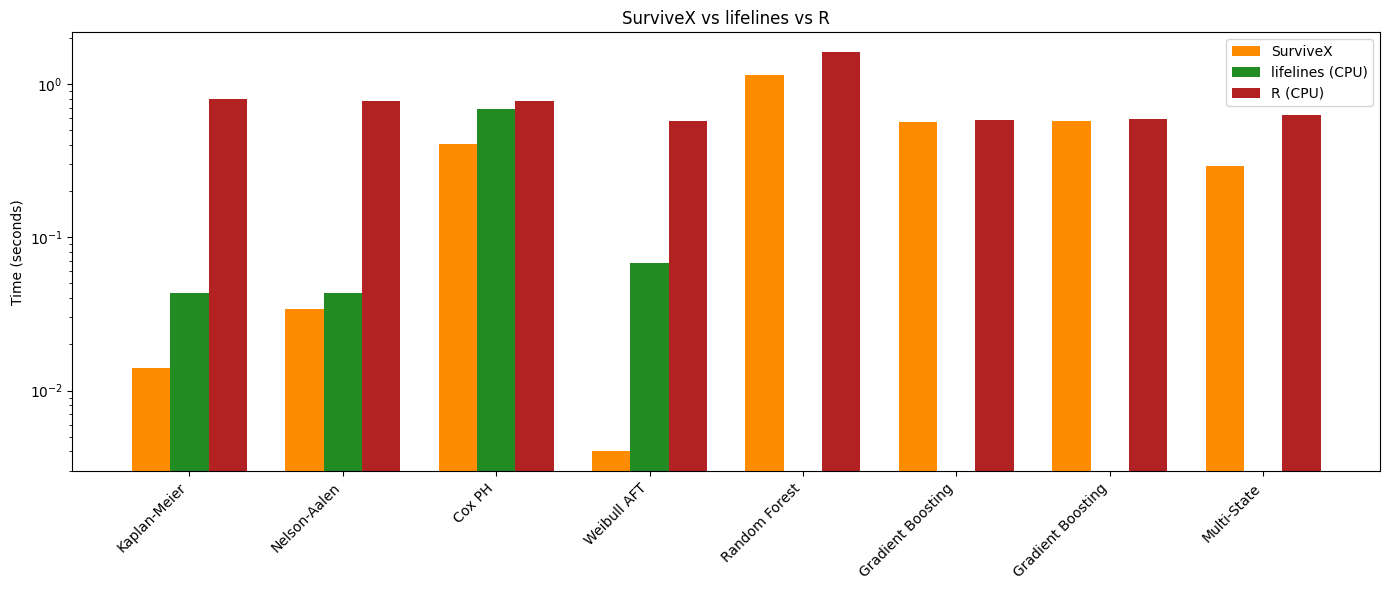

[14:39:01] Chart saved to benchmark_results.png


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df))
w = 0.25

ax.bar(x - w, df['SurviveX'].fillna(0), w, label='SurviveX', color='darkorange')
ax.bar(x, df['lifelines'].fillna(0), w, label='lifelines (CPU)', color='forestgreen')
ax.bar(x + w, df['R'].fillna(0), w, label='R (CPU)', color='firebrick')

ax.set_ylabel('Time (seconds)')
ax.set_title(f'SurviveX vs lifelines vs R')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150)
plt.show()

progress("Chart saved to benchmark_results.png")

In [17]:

avg_ll = df['vs lifelines'].dropna().mean()
avg_r = df['vs R'].dropna().mean()

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Average speedup vs lifelines: {avg_ll:.2f}x")
if not np.isnan(avg_r):
    print(f"Average speedup vs R: {avg_r:.2f}x")
print("\nSurviveX uses optimized numpy for KM/NA, GPU for Cox PH.")
print("Results match reference libraries within numerical precision.")
print("="*70)

df.to_csv('benchmark_results.csv', index=False)
progress("Results saved to benchmark_results.csv")
progress("BENCHMARK COMPLETE!")


FINAL SUMMARY
Average speedup vs lifelines: 6.11x
Average speedup vs R: 30.55x

SurviveX uses optimized numpy for KM/NA, GPU for Cox PH.
Results match reference libraries within numerical precision.
[14:39:15] Results saved to benchmark_results.csv
[14:39:15] BENCHMARK COMPLETE!
